In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline

import xgboost as xgb
import lightgbm as lgb

import joblib
import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Load Feature Engineered Data
df = pd.read_csv("../transaction_data.csv")

print("Data Shape:", df.shape)
print("\nTarget Distribution:")
print(df["isFraud"].value_counts())
print("\nFraud Percentage:")
print(df["isFraud"].value_counts(normalize=True) * 100)

display(df.head())

Data Shape: (6362620, 31)

Target Distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Fraud Percentage:
isFraud
0    99.870918
1     0.129082
Name: proportion, dtype: float64


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,is_oldbalanceOrg_zero,...,amount_to_oldbalance_dest_ratio,sender_account_emptied,dest_received_large_amount,is_large_transaction,step_bucket,transactions_in_step,is_high_velocity_step,is_dest_high_balance,type_risk_score,suspicious_signal_count
0,1,9839.64,170136.0,160296.36,0.0,0.0,0,0,3,0,...,0.000000,0,0,0,0,2708,0,0,1,1
1,1,1864.28,21249.0,19384.72,0.0,0.0,0,0,3,0,...,0.000000,0,0,0,0,2708,0,0,1,1
2,1,181.00,181.0,0.00,0.0,0.0,1,0,4,0,...,0.000000,1,0,0,0,2708,0,0,3,2
3,1,181.00,181.0,0.00,21182.0,0.0,1,0,1,0,...,0.008545,1,0,0,0,2708,0,0,3,2
4,1,11668.14,41554.0,29885.86,0.0,0.0,0,0,3,0,...,0.000000,0,0,0,0,2708,0,0,1,1


In [3]:
# Drop target and irrelevant columns
drop_cols = ["isFraud", "isFlaggedFraud"]

X = df.drop(columns=drop_cols)
y = df["isFraud"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFeature Columns:")
print(list(X.columns))

Feature Matrix Shape: (6362620, 29)
Target Shape: (6362620,)

Feature Columns:
['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'type_encoded', 'is_oldbalanceOrg_zero', 'is_newbalanceOrig_zero', 'is_oldbalanceDest_zero', 'is_newbalanceDest_zero', 'log_amount', 'balance_change_orig', 'expected_balance_change_orig', 'balance_error_orig', 'balance_change_dest', 'expected_balance_change_dest', 'balance_error_dest', 'amount_to_oldbalance_orig_ratio', 'amount_to_oldbalance_dest_ratio', 'sender_account_emptied', 'dest_received_large_amount', 'is_large_transaction', 'step_bucket', 'transactions_in_step', 'is_high_velocity_step', 'is_dest_high_balance', 'type_risk_score', 'suspicious_signal_count']


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y  # Important for imbalanced data
)

print("Training Set Shape:", X_train.shape)
print("Test Set Shape:", X_test.shape)

print("\nTraining Target Distribution:")
print(y_train.value_counts())

print("\nTest Target Distribution:")
print(y_test.value_counts())

Training Set Shape: (5090096, 29)
Test Set Shape: (1272524, 29)

Training Target Distribution:
isFraud
0    5083526
1       6570
Name: count, dtype: int64

Test Target Distribution:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


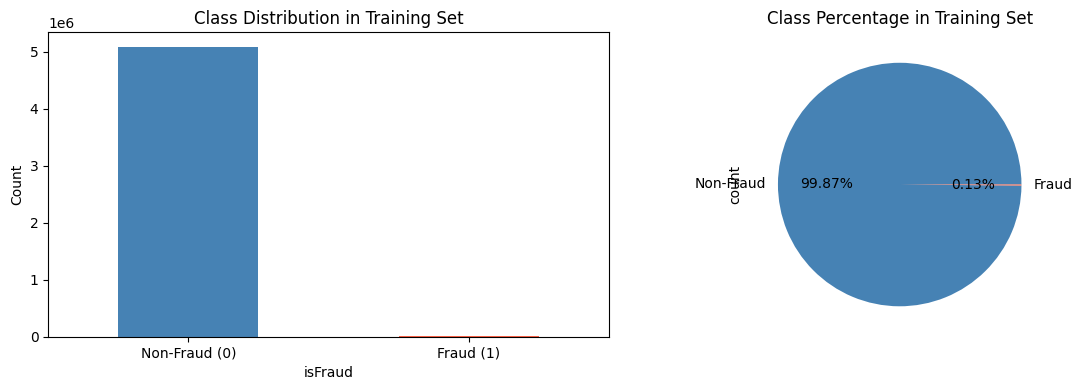


Class Imbalance Ratio: 1 fraud for every 774 non-fraud transactions


In [5]:
# Class Imbalance - Understand the Problem

# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
y_train.value_counts().plot(
    kind="bar",
    ax=axes[0],
    color=["steelblue", "tomato"]
)
axes[0].set_title("Class Distribution in Training Set")
axes[0].set_xticklabels(["Non-Fraud (0)", "Fraud (1)"], rotation=0)
axes[0].set_ylabel("Count")

# Percentage pie chart
y_train.value_counts().plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.2f%%",
    labels=["Non-Fraud", "Fraud"],
    colors=["steelblue", "tomato"]
)
axes[1].set_title("Class Percentage in Training Set")

plt.tight_layout()
plt.show()

print(f"\nClass Imbalance Ratio: 1 fraud for every {round(y_train.value_counts()[0] / y_train.value_counts()[1])} non-fraud transactions")

In [6]:
import numpy as np

# (Optional but recommended) memory reduce: float32
X_train = X_train.astype(np.float32)
X_test  = X_test.astype(np.float32)

# Keep all fraud, sample non-fraud
NEG_POS_RATIO = 30  # start with 30; if RAM low, try 20. If RAM ok, try 50.

fraud_idx = y_train[y_train == 1].index
nonfraud_idx = y_train[y_train == 0].index

n_fraud = len(fraud_idx)
n_nonfraud_needed = min(len(nonfraud_idx), n_fraud * NEG_POS_RATIO)

np.random.seed(42)
nonfraud_sample_idx = np.random.choice(nonfraud_idx, size=n_nonfraud_needed, replace=False)

selected_idx = np.concatenate([fraud_idx, nonfraud_sample_idx])

X_train_resampled = X_train.loc[selected_idx].copy()
y_train_resampled = y_train.loc[selected_idx].copy()

# Shuffle resampled train set
perm = np.random.permutation(len(selected_idx))
X_train_resampled = X_train_resampled.iloc[perm]
y_train_resampled = y_train_resampled.iloc[perm]

print("Original Train Shape:", X_train.shape)
print("Original Fraud %:", round(y_train.mean() * 100, 4))

print("\nResampled Train Shape:", X_train_resampled.shape)
print("Resampled Fraud %:", round(y_train_resampled.mean() * 100, 4))
print("\nResampled class counts:\n", y_train_resampled.value_counts())

Original Train Shape: (5090096, 29)
Original Fraud %: 0.1291

Resampled Train Shape: (203670, 29)
Resampled Fraud %: 3.2258

Resampled class counts:
 isFraud
0    197100
1      6570
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, average_precision_score
)

def evaluate_model(model_name, y_true, y_pred, y_prob):
    print(f"\n{'='*70}")
    print(f"Model: {model_name}")
    print(f"{'='*70}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=["Non-Fraud", "Fraud"]))

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    print(f"ROC-AUC : {roc_auc:.4f}")
    print(f"PR-AUC  : {pr_auc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Non-Fraud","Fraud"],
                yticklabels=["Non-Fraud","Fraud"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.ylabel("Actual")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

    return {"model": model_name, "roc_auc": roc_auc, "pr_auc": pr_auc}